# Credit Default Prediction

## Project Objective

The objective of this project is to predict whether an individual is likely to default on their credit based on their financial history.

## Approach

This project uses machine learning classification algorithms to predict credit default. The models explored include Logistic Regression, Decision Tree, and Random Forest.

## Key Components

* Exploratory Data Analysis
* Data preprocessing
* Feature engineering from financial data
* Feature selection
* Classification model development
* Model comparison
* Model evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
* Confusion Matrix and ROC Curve analysis
* Cross-validation
* Hyperparameter tuning
* Feature importance analysis


In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

## 1. Dataset Loading

The dataset will be loaded and examined to understand its structure, features, data types, and missing values.


In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
data = pd.read_csv("/content/drive/MyDrive/credit_data.csv")

In [62]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape:
(100, 6)

Column Names:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'EmploymentYears', 'Default']

Data Types:
Age                int64
Income             int64
LoanAmount         int64
CreditScore        int64
EmploymentYears    int64
Default            int64
dtype: object

Missing Values:
Age                0
Income             0
LoanAmount         0
CreditScore        0
EmploymentYears    0
Default            0
dtype: int64


In [63]:
data.head()

,Age,Income,LoanAmount,CreditScore,EmploymentYears,Default
0,59,32666,28664,803,11,0
1,49,58660,6636,691,20,0
2,35,23561,25080,434,0,0
3,63,46854,32728,494,25,0
4,28,84505,31736,700,25,0


## 2. Dataset Understanding

Before building the classification models, the dataset is examined to understand its structure, feature types, missing values, and target variable.


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              100 non-null    int64
 1   Income           100 non-null    int64
 2   LoanAmount       100 non-null    int64
 3   CreditScore      100 non-null    int64
 4   EmploymentYears  100 non-null    int64
 5   Default          100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [65]:
print(data["Default"].value_counts())

Default
0    77
1    23
Name: count, dtype: int64


In [66]:
print(data["Default"].value_counts(normalize=True) * 100)

Default
0    77.0
1    23.0
Name: proportion, dtype: float64


In [67]:
data.describe()

,Age,Income,LoanAmount,CreditScore,EmploymentYears,Default
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,42.030000,73084.820000,26576.580000,558.520000,14.510000,0.230000
std,12.919686,29332.285582,13425.117072,164.248855,9.559484,0.422953
min,21.000000,20206.000000,5197.000000,304.000000,0.000000,0.000000
25%,31.000000,46063.500000,13548.750000,415.750000,4.000000,0.000000
50%,42.000000,74326.000000,26918.500000,559.000000,15.000000,0.000000
75%,53.250000,98779.500000,36889.750000,692.000000,23.000000,0.000000
max,64.000000,118806.000000,49542.000000,846.000000,29.000000,1.000000


## 3. Data Cleaning

The dataset was checked for missing values, duplicate records, and data types before proceeding with exploratory analysis and model development.

In [68]:
# Check for duplicate records

print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [69]:
print(data.isnull().sum())

Age                0
Income             0
LoanAmount         0
CreditScore        0
EmploymentYears    0
Default            0
dtype: int64


In [70]:
print("Unique values in Default:", data["Default"].unique())

Unique values in Default: [0 1]


In [71]:


print("Age:", data["Age"].min(), "to", data["Age"].max())
print("Income:", data["Income"].min(), "to", data["Income"].max())
print("Loan Amount:", data["LoanAmount"].min(), "to", data["LoanAmount"].max())
print("Credit Score:", data["CreditScore"].min(), "to", data["CreditScore"].max())
print("Employment Years:", data["EmploymentYears"].min(), "to", data["EmploymentYears"].max())

Age: 21 to 64
Income: 20206 to 118806
Loan Amount: 5197 to 49542
Credit Score: 304 to 846
Employment Years: 0 to 29


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of the financial features and identify relationships between the input variables and credit default.


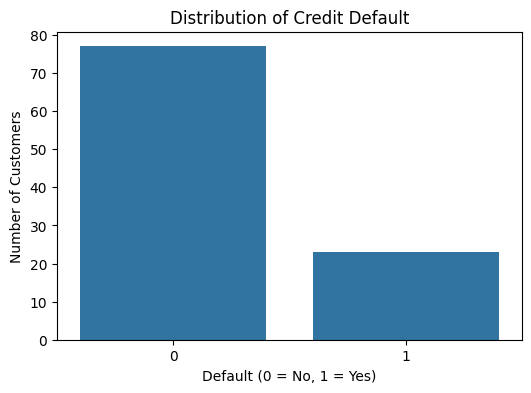

In [72]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Default", data=data)

plt.title("Distribution of Credit Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

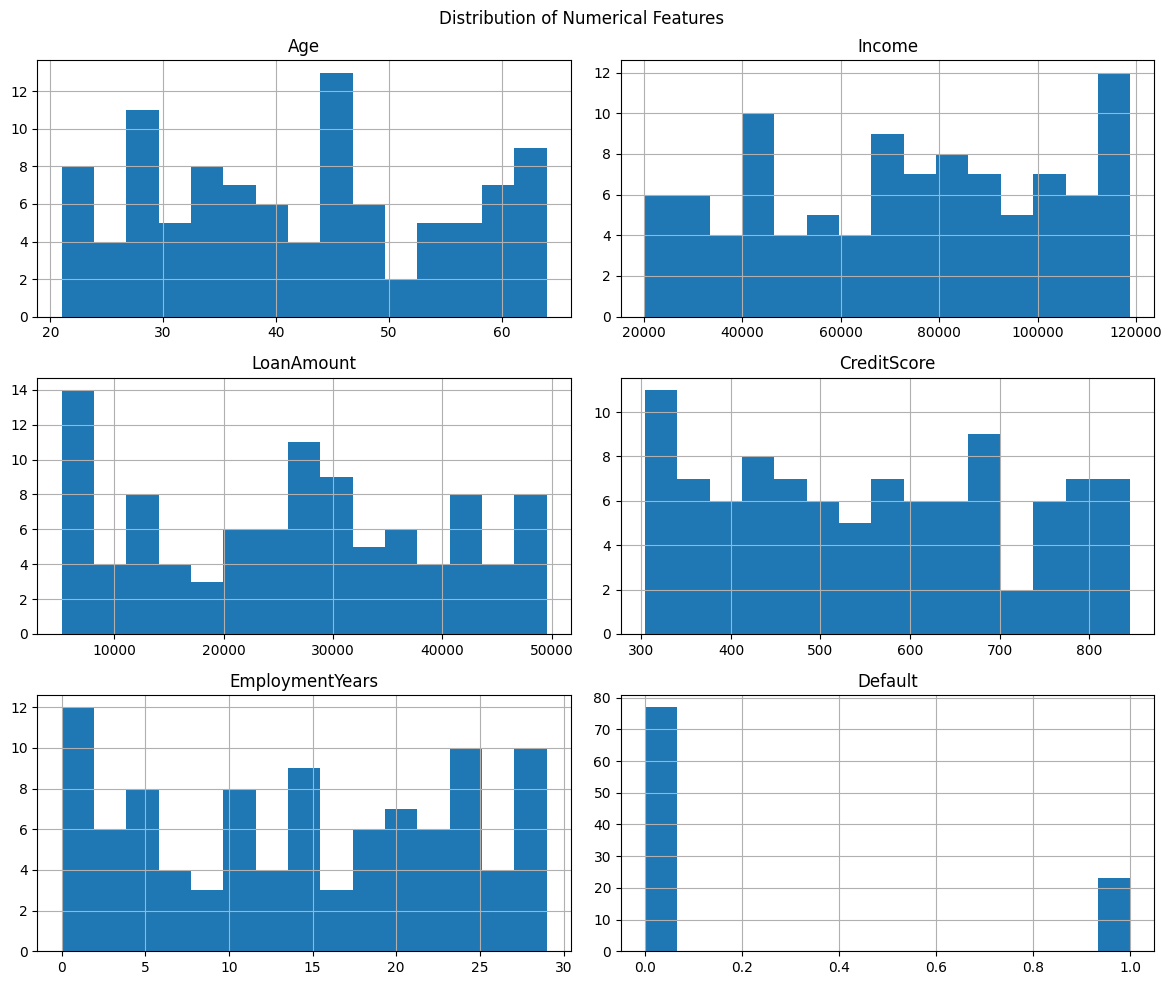

In [73]:
data.hist(
    figsize=(12, 10),
    bins=15
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

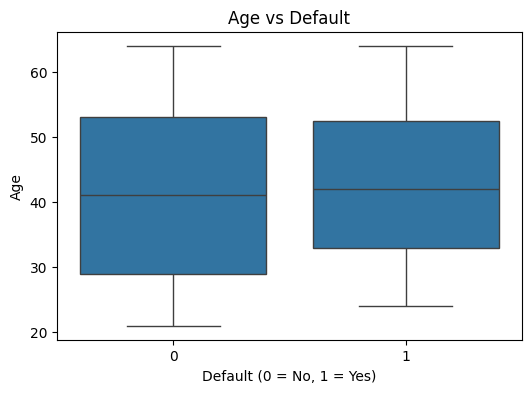

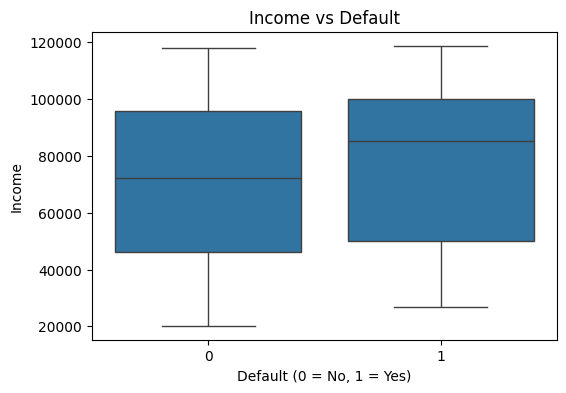

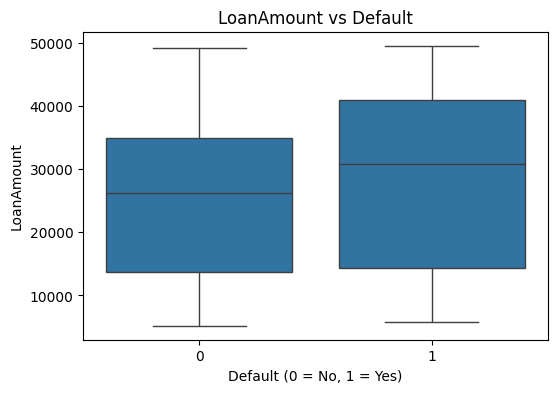

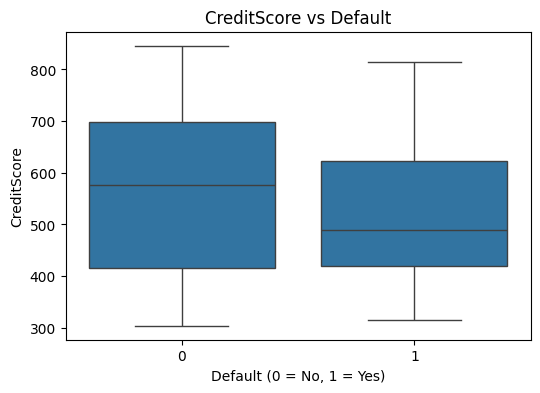

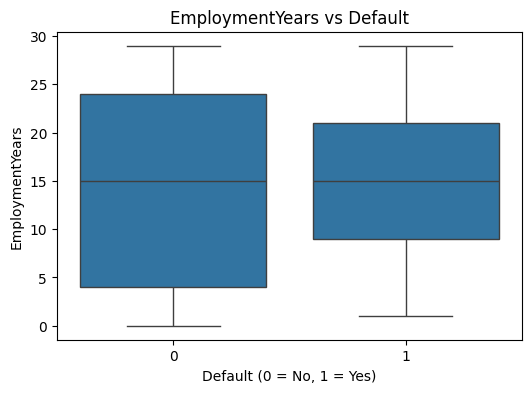

In [74]:
features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "EmploymentYears"
]

for feature in features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x="Default",
        y=feature,
        data=data
    )

    plt.title(f"{feature} vs Default")
    plt.xlabel("Default (0 = No, 1 = Yes)")
    plt.ylabel(feature)

    plt.show()

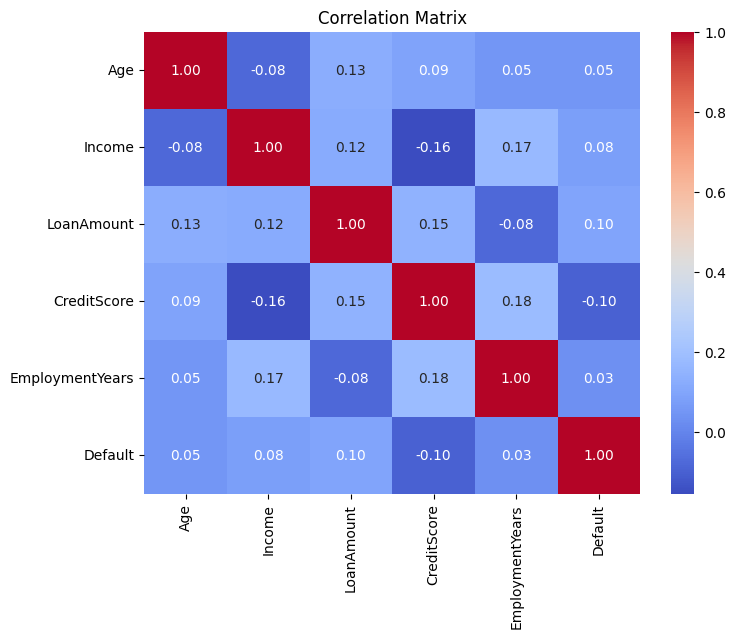

In [75]:
plt.figure(figsize=(8, 6))

correlation = data.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [76]:
data.groupby("Default")[
    ["Age", "Income", "LoanAmount", "CreditScore", "EmploymentYears"]
].mean()

,Age,Income,LoanAmount,CreditScore,EmploymentYears
Default,,,,,
0,41.688312,71859.766234,25868.415584,567.324675,14.337662
1,43.173913,77186.086957,28947.391304,529.043478,15.086957


## 5. Feature Engineering

Feature engineering is performed to create meaningful financial indicators from the existing variables. The engineered features are designed to represent relationships between income, loan amount, credit history, age, and employment experience.

In [77]:
data["Loan_to_Income"] = data["LoanAmount"] / data["Income"]

In [78]:
data["Income_per_EmploymentYear"] = (
    data["Income"] / (data["EmploymentYears"] + 1)
)

In [79]:
data["Loan_per_EmploymentYear"] = (
    data["LoanAmount"] / (data["EmploymentYears"] + 1)
)

In [80]:
data["CreditScore_Income"] = (
    data["CreditScore"] * data["Income"]
)

In [81]:
data["Age_Employment"] = (
    data["Age"] * data["EmploymentYears"]
)

In [82]:
data.head()

,Age,Income,LoanAmount,CreditScore,EmploymentYears,Default,Loan_to_Income,Income_per_EmploymentYear,Loan_per_EmploymentYear,CreditScore_Income,Age_Employment
0,59,32666,28664,803,11,0,0.877487,2722.166667,2388.666667,26230798,649
1,49,58660,6636,691,20,0,0.113126,2793.333333,316.000000,40534060,980
2,35,23561,25080,434,0,0,1.064471,23561.000000,25080.000000,10225474,0
3,63,46854,32728,494,25,0,0.698510,1802.076923,1258.769231,23145876,1575
4,28,84505,31736,700,25,0,0.375552,3250.192308,1220.615385,59153500,700


In [83]:
print("Original number of features: 5")
print("New number of features:", len(data.columns) - 1)

print("\nFeatures:")
print(data.columns.tolist())

Original number of features: 5
New number of features: 10

Features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'EmploymentYears', 'Default', 'Loan_to_Income', 'Income_per_EmploymentYear', 'Loan_per_EmploymentYear', 'CreditScore_Income', 'Age_Employment']


## 6. Data Preparation for Modeling

The target variable is separated from the input features. The dataset is then divided into training and testing sets. Feature scaling is applied using only the training data to prevent data leakage.

In [84]:


X = data.drop("Default", axis=1)
y = data["Default"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Default")

Features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'EmploymentYears', 'Loan_to_Income', 'Income_per_EmploymentYear', 'Loan_per_EmploymentYear', 'CreditScore_Income', 'Age_Employment']

Target:
Default


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80
Testing samples: 20


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [87]:
X_train_scaled = scaler.fit_transform(X_train)

In [88]:
X_test_scaled = scaler.transform(X_test)

## 7. Baseline Model — Logistic Regression

Logistic Regression is used as the baseline classification model. The baseline provides a reference point against which the performance of the engineered features and other classification algorithms can be compared.

In [89]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [90]:
baseline_pred = baseline_model.predict(X_test_scaled)

print("Baseline Predictions:")
print(baseline_pred)

Baseline Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


## 8. Baseline Model Evaluation

The baseline model is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics provide a more complete assessment than accuracy alone, especially because the target classes are not perfectly balanced.

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_results = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1-Score": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob)
}

baseline_results

{'Accuracy': 0.7,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': np.float64(0.3466666666666667)}

## 9. Baseline vs Feature-Engineered Model

The baseline model uses only the original financial features. Its performance is compared with a model trained using the engineered features to determine whether feature engineering improves predictive performance.

In [92]:


original_features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "EmploymentYears"
]

X_original = data[original_features]

print("Original features:")
print(X_original.columns.tolist())

Original features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'EmploymentYears']


In [93]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train_original.shape[0])
print("Testing samples:", X_test_original.shape[0])

Training samples: 80
Testing samples: 20


In [94]:
original_scaler = StandardScaler()

X_train_original_scaled = original_scaler.fit_transform(
    X_train_original
)

X_test_original_scaled = original_scaler.transform(
    X_test_original
)

In [95]:
original_baseline = LogisticRegression(
    random_state=42,
    max_iter=1000
)

original_baseline.fit(
    X_train_original_scaled,
    y_train_original
)

print("Original-feature baseline trained successfully.")

Original-feature baseline trained successfully.


In [96]:
original_pred = original_baseline.predict(
    X_test_original_scaled
)

original_prob = original_baseline.predict_proba(
    X_test_original_scaled
)[:, 1]

In [97]:
original_baseline_results = {
    "Accuracy": accuracy_score(
        y_test_original,
        original_pred
    ),

    "Precision": precision_score(
        y_test_original,
        original_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_original,
        original_pred,
        zero_division=0
    ),

    "F1-Score": f1_score(
        y_test_original,
        original_pred,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test_original,
        original_prob
    )
}

original_baseline_results

{'Accuracy': 0.65,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': np.float64(0.28)}

In [98]:
comparison = pd.DataFrame({
    "Original Features": original_baseline_results,
    "Engineered Features": baseline_results
})

comparison

,Original Features,Engineered Features
Accuracy,0.65,0.700000
Precision,0.00,0.000000
Recall,0.00,0.000000
F1-Score,0.00,0.000000
ROC-AUC,0.28,0.346667


## 10. Confusion Matrix

The confusion matrix is used to examine the number of correctly and incorrectly classified non-default and default cases.

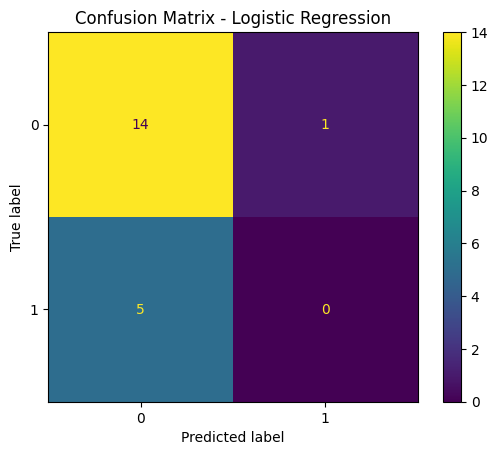

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [100]:
from sklearn.metrics import classification_report

In [101]:
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=[
            "Non-Default",
            "Default"
        ],
        zero_division=0
)
)

              precision    recall  f1-score   support

 Non-Default       0.74      0.93      0.82        15
     Default       0.00      0.00      0.00         5

    accuracy                           0.70        20
   macro avg       0.37      0.47      0.41        20
weighted avg       0.55      0.70      0.62        20



## 11. Decision Tree Classifier

A Decision Tree classifier is trained to capture non-linear relationships between the financial features and credit default.

In [102]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [103]:
dt_pred = decision_tree.predict(X_test)

dt_prob = decision_tree.predict_proba(X_test)[:, 1]

In [104]:
dt_results = {
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred, zero_division=0),
    "Recall": recall_score(y_test, dt_pred, zero_division=0),
    "F1-Score": f1_score(y_test, dt_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, dt_prob)
}

dt_results

{'Accuracy': 0.75,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': np.float64(0.42)}

## 12. Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees. It is used to model potentially non-linear relationships while reducing the dependence on a single decision tree.

In [105]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [106]:
rf_pred = random_forest.predict(X_test)

rf_prob = random_forest.predict_proba(X_test)[:, 1]

In [107]:
rf_results = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1-Score": f1_score(y_test, rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

rf_results

{'Accuracy': 0.75,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': np.float64(0.21333333333333335)}

In [108]:
model_comparison = pd.DataFrame({
    "Logistic Regression": baseline_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results
}).T

model_comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.70,0.0,0.0,0.0,0.346667
Decision Tree,0.75,0.0,0.0,0.0,0.420000
Random Forest,0.75,0.0,0.0,0.0,0.213333


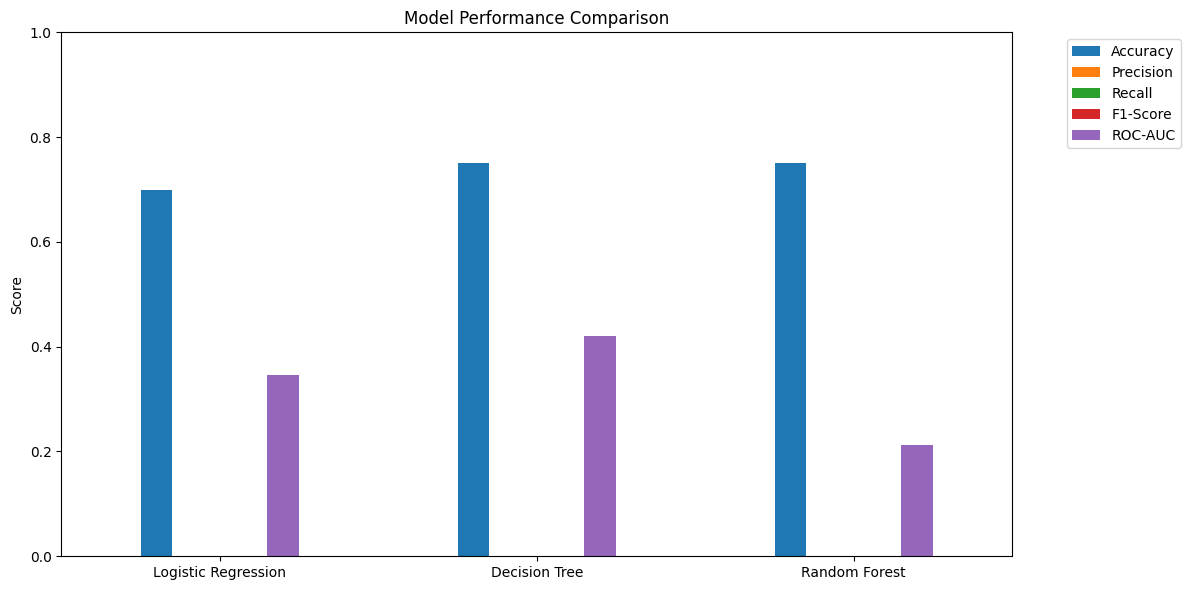

In [109]:
model_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 13. Analysis of Model Predictions

The initial model results are examined using the actual and predicted class distributions to understand whether the models are identifying both classes.

In [110]:
print("Actual test labels:")
print(y_test.value_counts())

print("\nLogistic Regression predictions:")
print(pd.Series(baseline_pred).value_counts())

print("\nDecision Tree predictions:")
print(pd.Series(dt_pred).value_counts())

print("\nRandom Forest predictions:")
print(pd.Series(rf_pred).value_counts())

Actual test labels:
Default
0    15
1     5
Name: count, dtype: int64

Logistic Regression predictions:
0    19
1     1
Name: count, dtype: int64

Decision Tree predictions:
0    20
Name: count, dtype: int64

Random Forest predictions:
0    20
Name: count, dtype: int64


In [111]:
from sklearn.metrics import confusion_matrix

In [112]:
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Logistic Regression Confusion Matrix:
[[14  1]
 [ 5  0]]

Decision Tree Confusion Matrix:
[[15  0]
 [ 5  0]]

Random Forest Confusion Matrix:
[[15  0]
 [ 5  0]]


## 13. Handling Class Imbalance

The target variable contains more non-default cases than default cases. Class-weighted classification is therefore explored to give greater importance to the minority default class.

In [113]:
balanced_lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

balanced_lr.fit(
    X_train_scaled,
    y_train
)

balanced_lr_pred = balanced_lr.predict(X_test_scaled)
balanced_lr_prob = balanced_lr.predict_proba(X_test_scaled)[:, 1]

In [114]:
balanced_lr_results = {
    "Accuracy": accuracy_score(y_test, balanced_lr_pred),
    "Precision": precision_score(y_test, balanced_lr_pred, zero_division=0),
    "Recall": recall_score(y_test, balanced_lr_pred, zero_division=0),
    "F1-Score": f1_score(y_test, balanced_lr_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, balanced_lr_prob)
}

balanced_lr_results

{'Accuracy': 0.5,
 'Precision': 0.14285714285714285,
 'Recall': 0.2,
 'F1-Score': 0.16666666666666666,
 'ROC-AUC': np.float64(0.3466666666666667)}

In [115]:
balanced_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    max_depth=5
)

balanced_rf.fit(
    X_train,
    y_train
)

balanced_rf_pred = balanced_rf.predict(X_test)
balanced_rf_prob = balanced_rf.predict_proba(X_test)[:, 1]

In [116]:
balanced_rf_results = {
    "Accuracy": accuracy_score(y_test, balanced_rf_pred),
    "Precision": precision_score(y_test, balanced_rf_pred, zero_division=0),
    "Recall": recall_score(y_test, balanced_rf_pred, zero_division=0),
    "F1-Score": f1_score(y_test, balanced_rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, balanced_rf_prob)
}

balanced_rf_results

{'Accuracy': 0.75,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': np.float64(0.24)}

In [117]:
balanced_comparison = pd.DataFrame({
    "Original Logistic Regression": baseline_results,
    "Balanced Logistic Regression": balanced_lr_results,
    "Original Random Forest": rf_results,
    "Balanced Random Forest": balanced_rf_results
}).T

balanced_comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Original Logistic Regression,0.70,0.000000,0.0,0.000000,0.346667
Balanced Logistic Regression,0.50,0.142857,0.2,0.166667,0.346667
Original Random Forest,0.75,0.000000,0.0,0.000000,0.213333
Balanced Random Forest,0.75,0.000000,0.0,0.000000,0.240000


## 14. Stratified Cross-Validation

Because the dataset contains only 100 observations, a single train-test split may produce unstable evaluation results. Stratified K-Fold Cross-Validation is therefore used to evaluate model performance across multiple data splits while preserving the proportion of default and non-default cases.

In [118]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [119]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [120]:
cv_lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [123]:
from sklearn.metrics import make_scorer

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

In [124]:
cv_lr_results = cross_validate(
    cv_lr,
    X,
    y,
    cv=cv,
    scoring=scoring
)

In [125]:
cv_lr_summary = {
    "Accuracy": cv_lr_results["test_accuracy"].mean(),
    "Precision": cv_lr_results["test_precision"].mean(),
    "Recall": cv_lr_results["test_recall"].mean(),
    "F1-Score": cv_lr_results["test_f1"].mean(),
    "ROC-AUC": cv_lr_results["test_roc_auc"].mean()
}

cv_lr_summary

{'Accuracy': np.float64(0.53),
 'Precision': np.float64(0.20595238095238094),
 'Recall': np.float64(0.33999999999999997),
 'F1-Score': np.float64(0.2554112554112554),
 'ROC-AUC': np.float64(0.5078750000000001)}

In [127]:
cv_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=5,
    random_state=42
)

In [128]:
cv_rf_results = cross_validate(
    cv_rf,
    X,
    y,
    cv=cv,
    scoring=scoring
)

In [129]:
cv_rf_summary = {
    "Accuracy": cv_rf_results["test_accuracy"].mean(),
    "Precision": cv_rf_results["test_precision"].mean(),
    "Recall": cv_rf_results["test_recall"].mean(),
    "F1-Score": cv_rf_results["test_f1"].mean(),
    "ROC-AUC": cv_rf_results["test_roc_auc"].mean()
}

cv_rf_summary

{'Accuracy': np.float64(0.73),
 'Precision': np.float64(0.25),
 'Recall': np.float64(0.13),
 'F1-Score': np.float64(0.16825396825396827),
 'ROC-AUC': np.float64(0.4936249999999999)}

In [130]:
cv_comparison = pd.DataFrame({
    "Balanced Logistic Regression": cv_lr_summary,
    "Balanced Random Forest": cv_rf_summary
}).T

cv_comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Balanced Logistic Regression,0.53,0.205952,0.34,0.255411,0.507875
Balanced Random Forest,0.73,0.250000,0.13,0.168254,0.493625


## 15. ROC Curve Analysis

ROC curves are used to evaluate the ability of the classification models to distinguish between default and non-default cases across different classification thresholds.

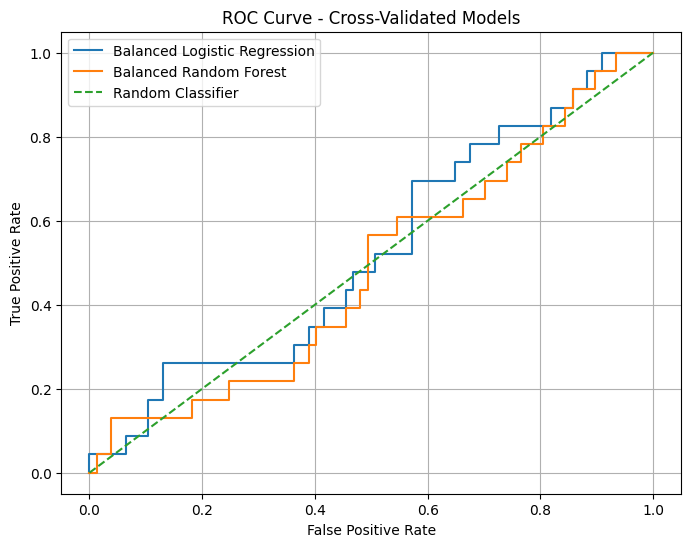

In [131]:
from sklearn.model_selection import cross_val_predict

# Cross-validated probability predictions
lr_cv_prob = cross_val_predict(
    cv_lr,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

rf_cv_prob = cross_val_predict(
    cv_rf,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# ROC curve values
lr_fpr, lr_tpr, _ = roc_curve(y, lr_cv_prob)
rf_fpr, rf_tpr, _ = roc_curve(y, rf_cv_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Balanced Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Balanced Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cross-Validated Models")
plt.legend()
plt.grid()
plt.show()

## 16. Feature Importance

Feature importance is examined to understand which engineered financial features contribute most to the Random Forest model's predictions.

In [132]:

final_rf_for_importance = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=5,
    random_state=42
)

final_rf_for_importance.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_rf_for_importance.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,Income_per_EmploymentYear,0.165182
5,Loan_to_Income,0.115291
3,CreditScore,0.114928
7,Loan_per_EmploymentYear,0.108678
2,LoanAmount,0.098527
1,Income,0.091980
9,Age_Employment,0.087927
8,CreditScore_Income,0.082762
0,Age,0.080388
4,EmploymentYears,0.054339


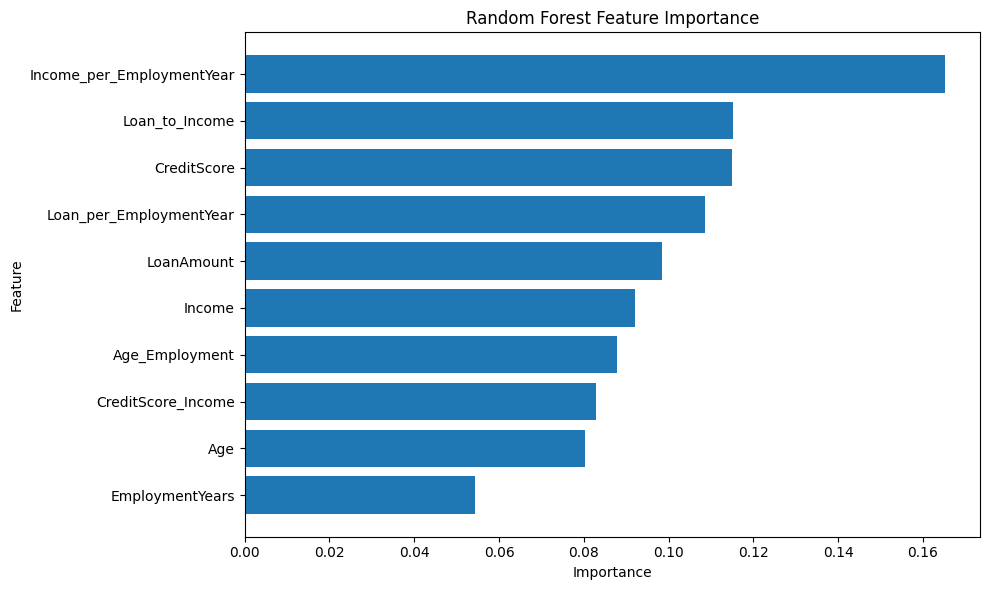

In [133]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 17. Hyperparameter Tuning

Grid Search is used to evaluate different Random Forest hyperparameter combinations using stratified cross-validation.

In [134]:
from sklearn.model_selection import GridSearchCV

rf_for_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [135]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

Best Cross-Validation F1-Score:
0.22444444444444445


In [136]:
tuned_rf = grid_search.best_estimator_

In [137]:
tuned_rf_pred = cross_val_predict(
    tuned_rf,
    X,
    y,
    cv=cv,
    method="predict"
)

tuned_rf_prob = cross_val_predict(
    tuned_rf,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [138]:
tuned_rf_results = {
    "Accuracy": accuracy_score(y, tuned_rf_pred),
    "Precision": precision_score(
        y,
        tuned_rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y,
        tuned_rf_pred,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y,
        tuned_rf_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y,
        tuned_rf_prob
    )
}

tuned_rf_results

{'Accuracy': 0.75,
 'Precision': 0.4,
 'Recall': 0.17391304347826086,
 'F1-Score': 0.24242424242424243,
 'ROC-AUC': np.float64(0.5206098249576511)}

In [139]:
final_comparison = pd.DataFrame({
    "Balanced Logistic Regression": cv_lr_summary,
    "Balanced Random Forest": cv_rf_summary,
    "Tuned Random Forest": tuned_rf_results
}).T

final_comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Balanced Logistic Regression,0.53,0.205952,0.340000,0.255411,0.507875
Balanced Random Forest,0.73,0.250000,0.130000,0.168254,0.493625
Tuned Random Forest,0.75,0.400000,0.173913,0.242424,0.520610


In [140]:
final_comparison.to_csv(
    "/content/drive/MyDrive/credit_model_results.csv"
)

feature_importance.to_csv(
    "/content/drive/MyDrive/credit_feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


## 18. Classification Threshold Analysis

The classification threshold is varied to examine its effect on precision, recall, and F1-score. This helps analyze the trade-off between identifying potential default cases and avoiding unnecessary default predictions.

In [141]:
import numpy as np

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (
        tuned_rf_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.20,0.242857,0.739130,0.365591
1,0.25,0.250000,0.608696,0.354430
2,0.30,0.222222,0.434783,0.294118
3,0.35,0.216216,0.347826,0.266667
4,0.40,0.160000,0.173913,0.166667
5,0.45,0.222222,0.173913,0.195122
6,0.50,0.400000,0.173913,0.242424
7,0.55,0.375000,0.130435,0.193548
8,0.60,0.500000,0.086957,0.148148
9,0.65,0.333333,0.043478,0.076923


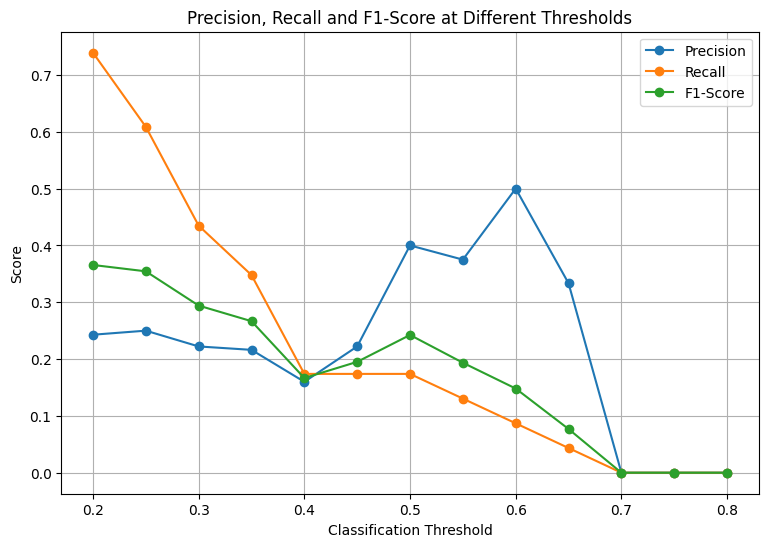

In [142]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score at Different Thresholds")
plt.legend()
plt.grid()

plt.show()

In [143]:
final_comparison.to_csv(
    "/content/drive/MyDrive/credit_model_results.csv"
)

feature_importance.to_csv(
    "/content/drive/MyDrive/credit_feature_importance.csv",
    index=False
)

threshold_df.to_csv(
    "/content/drive/MyDrive/credit_threshold_analysis.csv",
    index=False
)

print("All updated results saved to Google Drive.")

All updated results saved to Google Drive.
